<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_week9(168).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)
 My Best ObservationsWhen I run this code and look at the resulting feature maps, here is exactly what I observe happening inside the "mind" of the network:Observation 1: The Convolution Filters act like specialized flashlights. When I look at the Conv2D feature maps, I notice they don't look like a standard T-shirt anymore. Instead, each of the 16 filters has highlighted something entirely different. One filter might glow brightly only on the vertical edges (the sleeves), while another filter ignores the inside of the shirt entirely and only traces the glowing outer boundary. The network has broken the image down into its structural components.

 Observation 2: The ReLU Activation turns off the noise.I see a lot of deep purple/black space in the convolutional feature maps. Because the Conv2D layer uses a relu activation function, any pixel math that resulted in a negative number was instantly converted to zero. I observe that this effectively "deletes" the background and irrelevant textures, forcing the network to focus exclusively on the glowing positive features it found.

 Observation 3: Max Pooling preserves structure while destroying resolution.When I compare the Convolution maps to the Max Pooling maps, I observe that the spatial resolution is cut exactly in half (from $28 \times 28$ down to $14 \times 14$). The images look visibly more "blocky" and pixelated. However, the brightest pixels, the most important edges and shapes survived perfectly. I can confidently say that Pooling acts as a brilliant compression tool; it reduces the computational memory by 75% while keeping the exact geometric identity of the T-shirt intact.To help you visualize exactly how these mathematical kernels slide over a geometric shape to create these glowing edge maps, I have generated an interactive visualizer below. You can apply different convolution kernels to a simulated pixel-art T-shirt and watch how Pooling compresses it.

Quickly training model to initialize filters...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


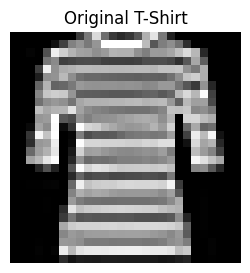

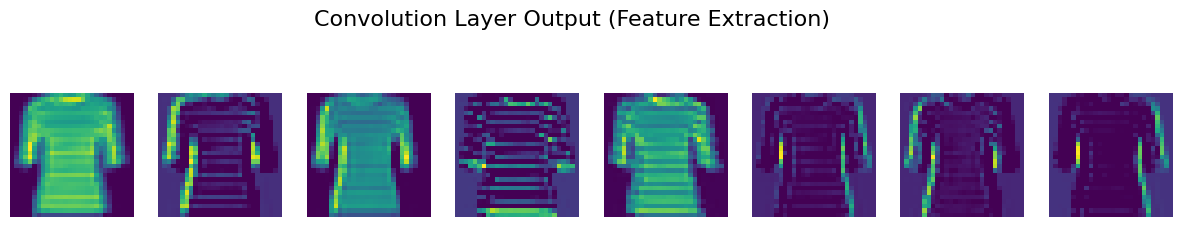

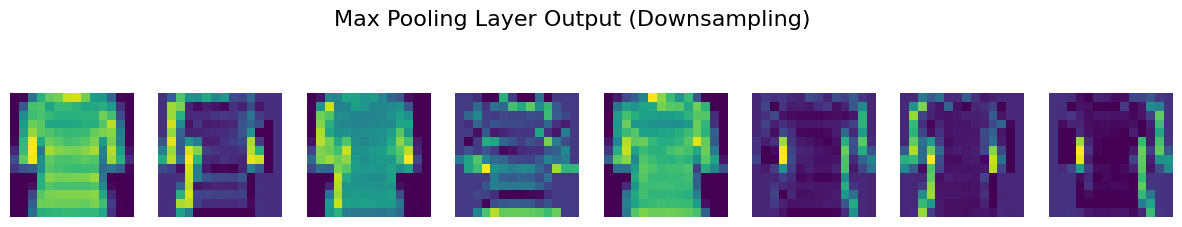

In [5]:
#This program builds a simple CNN, trains it very briefly so the filters learn basic shapes,
#and then uses a Model to "intercept" the image as it travels through the hidden layers.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data and Pick an Image
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Let's find the first 'T-shirt/top' (Label 0) in the dataset
shirt_idx = np.where(y_train == 0)[0][5]
image = x_train[shirt_idx].reshape(1, 28, 28, 1) / 255.0

# 2. Build and Quickly Train a Simple CNN
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu', name='my_conv'),
    tf.keras.layers.MaxPooling2D((2, 2), name='my_pool'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# We train for just 1 epoch so the filters learn basic edge detection
print("Quickly training model to initialize filters...")
model.fit(x_train.reshape(-1, 28, 28, 1) / 255.0, y_train, epochs=1, batch_size=256, verbose=0)

# 3. Create the "Extractor" Model
# ---------------------------------------------------------
# This new model takes the same input, but outputs the data from the Conv and Pool layers directly
extractor = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[model.get_layer('my_conv').output, model.get_layer('my_pool').output]
)

# Pass our single T-shirt image through the extractor
conv_features, pool_features = extractor.predict(image)

# 4. Visualization Function
def plot_feature_maps(feature_maps, title, num_filters=8):
    """Plots a grid of feature maps."""
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num_filters):
        plt.subplot(1, num_filters, i + 1)
        # feature_maps shape is (1, Height, Width, Filters)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.show()

# Display Original
plt.figure(figsize=(3, 3))
plt.imshow(image[0, :, :, 0], cmap='gray')
plt.title("Original T-Shirt")
plt.axis('off')
plt.show()

# Display Feature Maps
plot_feature_maps(conv_features, "Convolution Layer Output (Feature Extraction)")
plot_feature_maps(pool_features, "Max Pooling Layer Output (Downsampling)")